# 3. Supervised DNN Comparison

**Objective:** Train a supervised binary classifier on the same data and
compare its performance against the unsupervised autoencoder. This
establishes what performance looks like when fraud labels ARE used during
training.

**Architecture:** 4-layer DNN [256 -> 128 -> 64 -> 32] with BatchNorm,
ReLU, Dropout(0.3), outputting a single logit. Trained with
BCEWithLogitsLoss and pos_weight to handle class imbalance.

**Key difference from autoencoder:** This model sees fraud labels during
training. The autoencoder does not. Higher performance here is expected
but comes at the cost of requiring labeled data.

## 3.1 Setup

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, "..")

import numpy as np
import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.model import FraudDetectorDNN
from src.train import train_supervised
from src.evaluate import evaluate, find_optimal_threshold, get_predictions
from src.utils import (get_device, set_seed, plot_training_curves,
                       plot_confusion_matrix, plot_precision_recall_curve)
from src.dataset import FraudDataset

set_seed(42)
device = get_device()
print(f"Device: {device}")

data = load_processed("../data/processed", "../models")
print(f"Loaded. Input dim: {data['input_dim']}")

Device: mps


/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded. Input dim: 16


## 3.2 Build Supervised Training Set

The autoencoder split gives x_train = normal-only. For supervised training,
we need both classes. We merge the normal training data with half of the
validation set (which contains fraud), and use the other half as supervised
validation. The test set is kept identical for a fair comparison.

In [2]:
rng = np.random.default_rng(42)
perm = rng.permutation(len(data["y_val"]))
half = len(perm) // 2

# Half of val joins training, half stays as supervised val
x_train_extra = data["x_val"][perm[:half]]
y_train_extra = data["y_val"][perm[:half]]
x_new_val = data["x_val"][perm[half:]]
y_new_val = data["y_val"][perm[half:]]

# Merge: normal (label 0) + mixed (with fraud labels)
x_train = np.concatenate([data["x_train"], x_train_extra])
y_train = np.concatenate([np.zeros(len(data["x_train"]), dtype=np.int64), y_train_extra])

# Shuffle
perm_train = rng.permutation(len(y_train))
x_train, y_train = x_train[perm_train], y_train[perm_train]

print(f"Supervised train: {x_train.shape} (fraud rate: {y_train.mean():.4f})")
print(f"Supervised val:   {x_new_val.shape} (fraud rate: {y_new_val.mean():.4f})")
print(f"Test (shared):    {data['x_test'].shape} (fraud rate: {data['y_test'].mean():.4f})")

Supervised train: (1102772, 16) (fraud rate: 0.0168)
Supervised val:   (123393, 16) (fraud rate: 0.1492)
Test (shared):    (246787, 16) (fraud rate: 0.1496)


## 3.3 Build Data Loaders

In [3]:
BATCH_SIZE = 1024

train_ds = FraudDataset(x_train, y_train)
val_ds = FraudDataset(x_new_val, y_new_val)
test_ds = FraudDataset(data["x_test"], data["y_test"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# pos_weight for imbalanced BCE loss
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight.item():.2f}  (neg/pos ratio)")

pos_weight: 58.58  (neg/pos ratio)


## 3.4 Build Model

In [4]:
HIDDEN_DIMS = [256, 128, 64, 32]
DROPOUT = 0.3

model = FraudDetectorDNN(
    input_dim=data["input_dim"],
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture: {HIDDEN_DIMS}")
print(f"Trainable parameters: {n_params:,}")
print(model)

Architecture: [256, 128, 64, 32]
Trainable parameters: 48,577
FraudDetectorDNN(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3.5 Training

In [5]:
history = train_supervised(
    model, train_loader, val_loader, pos_weight, device,
    epochs=100, lr=1e-3, weight_decay=1e-5, patience=10,
)

print(f"\nBest epoch: {history['best_epoch']}")
print(f"Training time: {history['wall_time_sec']:.1f}s")

  Epoch   1/100  | Train Loss: 1.11131  | Val Loss: 5.39432  | LR: 1.00e-03
  Epoch   5/100  | Train Loss: 1.05096  | Val Loss: 5.13295  | LR: 1.00e-03
  Epoch  10/100  | Train Loss: 1.02961  | Val Loss: 5.23499  | LR: 1.00e-03
  Epoch  15/100  | Train Loss: 1.02341  | Val Loss: 5.09485  | LR: 1.00e-03
  Epoch  20/100  | Train Loss: 1.01990  | Val Loss: 5.09043  | LR: 5.00e-04
  Epoch  24/100  | Train Loss: 1.01310  | Val Loss: 5.19709  | LR: 5.00e-04
  Early stopping at epoch 24. Best epoch: 14
  Training completed in 797.5s

Best epoch: 14
Training time: 797.5s


Saved: ../figures/fig06_supervised_training_curves.png


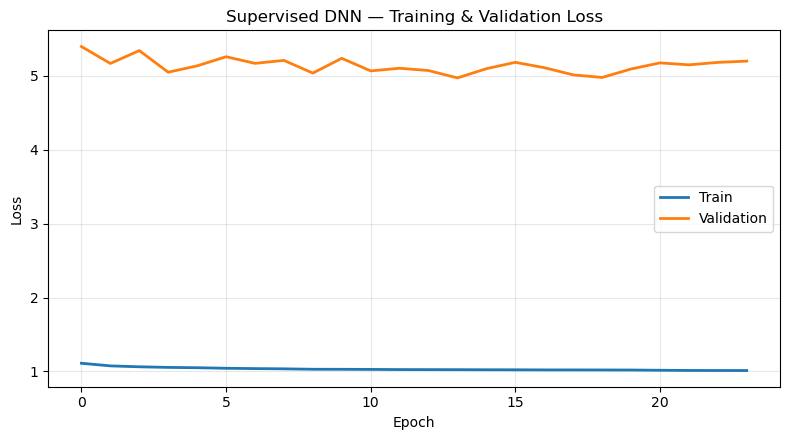

In [6]:
plot_training_curves(
    history,
    save_path="../figures/fig06_supervised_training_curves.png",
    title="Supervised DNN — Training & Validation Loss",
)

## 3.6 Threshold Tuning on Validation Set

In [7]:
val_probs, val_labels_sup = get_predictions(model, val_loader, device)
best_threshold = find_optimal_threshold(val_probs, val_labels_sup)

F1-optimal threshold: 0.6423  (precision=0.503, recall=0.550, f1=0.525)


## 3.7 Test Evaluation

In [8]:
test_probs, test_labels_sup = get_predictions(model, test_loader, device)
metrics_dnn = evaluate(test_probs, test_labels_sup, best_threshold, label="Test (DNN)")


  Test (DNN) Set Evaluation   (threshold = 0.642298)
              precision    recall  f1-score   support

      Normal     0.9199    0.9043    0.9121    209868
       Fraud     0.5040    0.5524    0.5271     36919

    accuracy                         0.8517    246787
   macro avg     0.7119    0.7284    0.7196    246787
weighted avg     0.8577    0.8517    0.8545    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        189794        20074
  True Fraud          16525        20394

  ROC-AUC:  0.8125
  PR-AUC:   0.5689  (better metric for imbalanced data)
  F1:       0.5271


Saved: ../figures/fig07_supervised_confusion_matrix.png


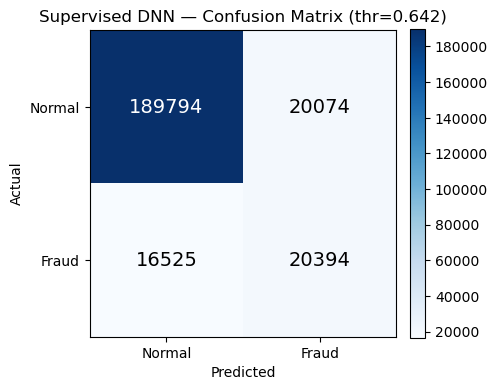

In [9]:
test_preds = (test_probs >= best_threshold).astype(int)
plot_confusion_matrix(
    test_labels_sup, test_preds,
    save_path="../figures/fig07_supervised_confusion_matrix.png",
    title=f"Supervised DNN — Confusion Matrix (thr={best_threshold:.3f})",
)

Saved: ../figures/fig08_supervised_pr_curve.png


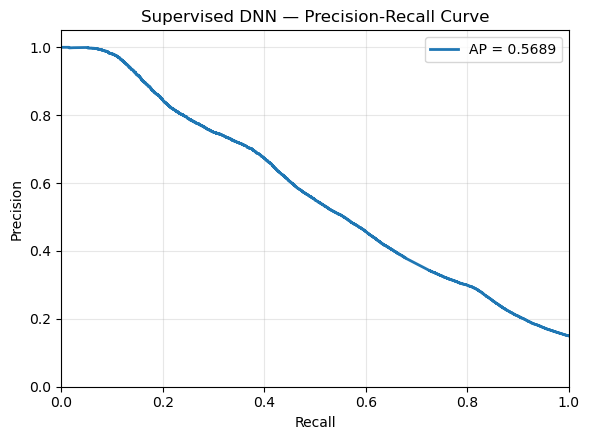

In [10]:
plot_precision_recall_curve(
    test_probs, test_labels_sup,
    save_path="../figures/fig08_supervised_pr_curve.png",
    title="Supervised DNN — Precision-Recall Curve",
)

## 3.8 Save Model

In [11]:
from src.utils import save_checkpoint

save_checkpoint(
    model,
    path="../models/supervised_best.pt",
    metadata={
        "model_type": "supervised_dnn",
        "input_dim": data["input_dim"],
        "hidden_dims": HIDDEN_DIMS,
        "dropout": DROPOUT,
        "threshold": best_threshold,
        "best_epoch": history["best_epoch"],
        "test_pr_auc": metrics_dnn["pr_auc"],
    },
)

Saved checkpoint to ../models/supervised_best.pt


## Summary

The supervised DNN uses fraud labels during training, which the autoencoder
does not. Compare these results against the autoencoder baseline (Notebook 1)
and the architecture variants (Notebook 2) in the final comparison (Notebook 4).

**Figures generated:**
- `fig06_supervised_training_curves.png`
- `fig07_supervised_confusion_matrix.png`
- `fig08_supervised_pr_curve.png`